Mittag-Leffler - codigo I (descarte)

Autor: Camila Borges Sena

E-mail: camila19sena@gmail.com

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma


In [8]:
def mittag_leffler(z, alpha, n_terms=60):
    z = np.array(z, dtype=np.float64)
    result = np.zeros_like(z)

    for k in range(n_terms):
        term = z**k / gamma(1 + alpha * k)
        result += term

        # critério simples de convergência
        if np.all(np.abs(term) < 1e-12):
            break

    return result


In [9]:
t = np.linspace(0, 3, 300)   # domínio menor
alphas = [0.4, 0.6, 0.8, 1.0]


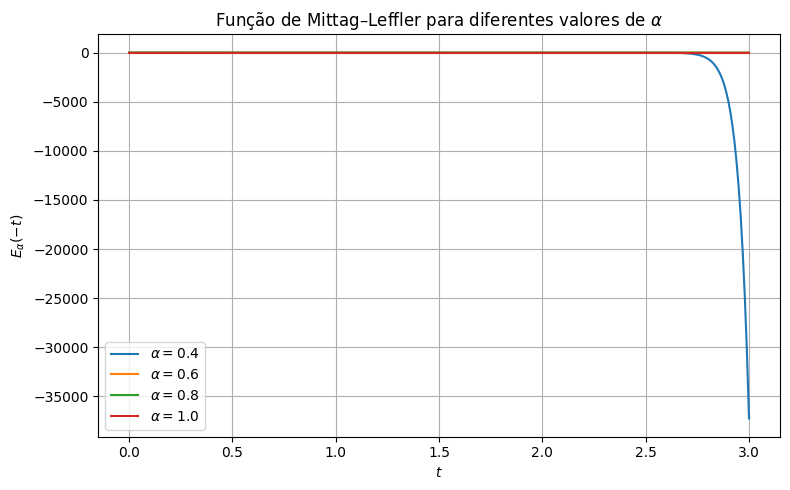

In [11]:
plt.figure(figsize=(8, 5))

for alpha in alphas:
    E = mittag_leffler(-t, alpha)
    plt.plot(t, E, label=rf"$\alpha={alpha}$")

plt.xlabel(r"$t$")
plt.ylabel(r"$E_\alpha(-t)$")
plt.title("Função de Mittag–Leffler para diferentes valores de $\\alpha$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



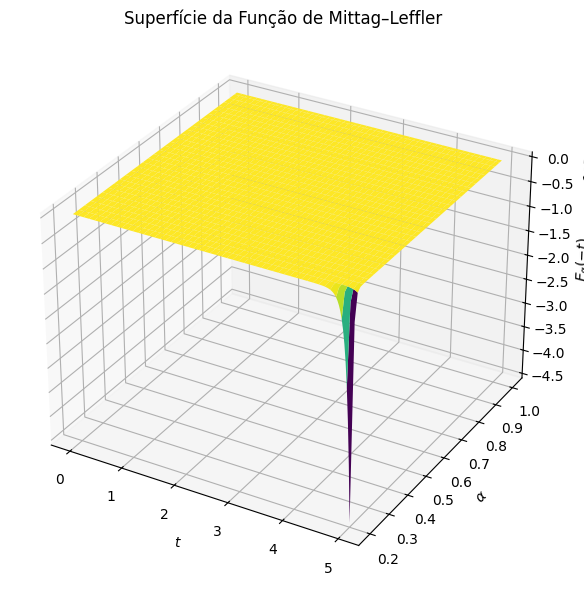

In [12]:
from mpl_toolkits.mplot3d import Axes3D

T, A = np.meshgrid(
    np.linspace(0, 5, 200),
    np.linspace(0.2, 1.0, 60)
)

E = np.zeros_like(T)

for i in range(A.shape[0]):
    for j in range(T.shape[1]):
        E[i, j] = mittag_leffler(-T[i, j], A[i, j])

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(T, A, E, cmap='viridis', edgecolor='none')
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\alpha$")
ax.set_zlabel(r"$E_\alpha(-t)$")
ax.set_title("Superfície da Função de Mittag–Leffler")

plt.tight_layout()
plt.show()
